### Zadanie 1.
W wybranymśrodowisku napisz program do wyznaczania następujących statystyk dla danego wektora
obserwacji: mediana, kwartyle, rozstęp z próby, rozstęp międzykwartylowy, wariancja z próby oraz
odchylenie standardowe. Wyznacz wartości powyższych charakterystyk dla wysymulowanej próby z
rozkładu normalnego z parametrami µ = 2 i σ = 2 o długości 2000 elementów. Otrzymane wyniki
porównaj z wynikami uzyskanymi za pomocą funkcji wbudowanych.

In [26]:
import numpy as np
import scipy.stats as sc

In [27]:
def median(T):
    T = np.sort(T)
    n = len(T)
    if n % 2 == 1:
        return T[n // 2]
    else:
        return 0.5 * (T[n // 2] + T[n // 2 - 1])
    
def quartile(T):
    T = np.sort(T)
    n = len(T)
    q1 = median(T[:n // 2])
    q2 = median(T)
    q3 = median(T[n // 2:])
    q4 = T[n - 1]
    return [q1, q2, q3, q4]

def range(T):
    return max(T) - min(T)

def IQR(T):
    a, _, b, _ = quartile(T)
    return b - a

def Var(T):
    n = len(T)
    mean = median(T)
    a = (T - mean)**2
    var = np.sum(a)
    var /= (n - 1)
    return var

mi = 2
sigma = 2
size = 2000

X = np.random.normal(2, 2, 2000)
print(X)
print(quartile(X))

[1.85092577 4.52924356 3.63403727 ... 1.1576578  2.51152783 2.06303449]
[0.7333739814184901, 2.03778461638288, 3.3707561875460517, 8.911013489841821]


### Zadanie 2
Na stronie internetowej https://vincentarelbundock.github.io/Rdatasets/datasets.html znajdź dowol
ne dane o co najmniej 1000 obserwacjach. Dla tych danych wyznacz średnią arytmetyczną, harmo
niczną oraz geometryczną. Ponadto przedstaw wykres średniej ucinanej i winsorowskiej jako funkcję
parametru k

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv(r'https://vincentarelbundock.github.io/Rdatasets/csv/AER/CPSSWEducation.csv')


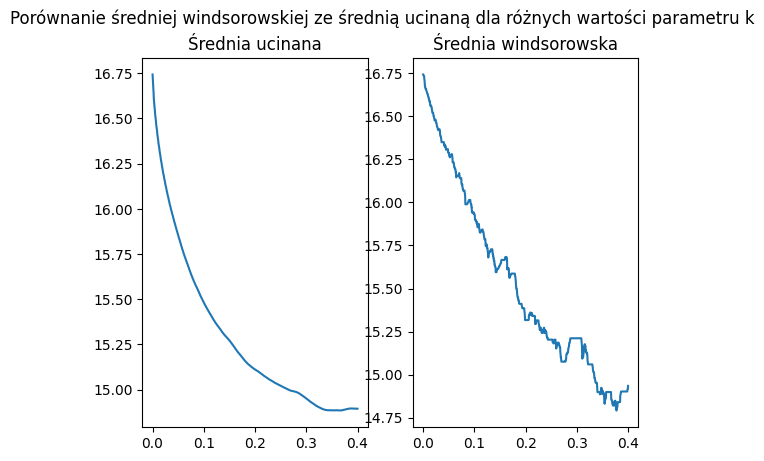

[14.682594621467368, 12.81726630571915, 16.742717344030506]

In [29]:
def z2():
    finance = data['earnings']
    g_mean = sc.gmean(finance)
    h_mean = sc.hmean(finance)
    a_mean = np.mean(finance)
    k = np.linspace(0, 0.4, 1000)
    t_mean = []
    w_mean = []
    for i in k:
        t_mean.append(sc.trim_mean(finance, i))
        w = sc.mstats.winsorize(finance, limits=i)
        w_mean.append(np.mean(w))

    fig, axs = plt.subplots(1, 2)
    fig.suptitle('Porównanie średniej windsorowskiej ze średnią ucinaną dla różnych wartości parametru k')
    axs[0].plot(k, t_mean)
    axs[0].set_title('Średnia ucinana')
    axs[1].plot(k, w_mean)
    axs[1].set_title('Średnia windsorowska')
    plt.show()
    return [g_mean, h_mean, a_mean]

z2()

0       30
1       30
2       30
3       30
4       30
        ..
2945    30
2946    30
2947    29
2948    29
2949    30
Name: age, Length: 2950, dtype: int64


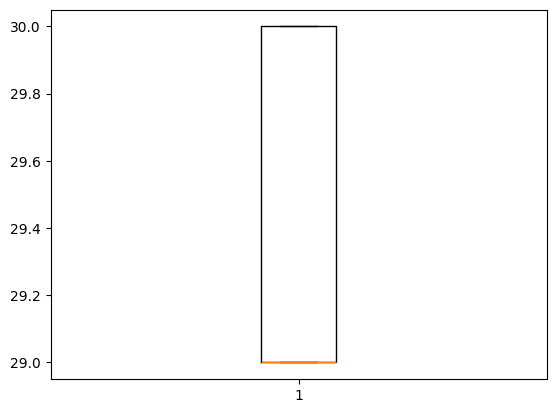

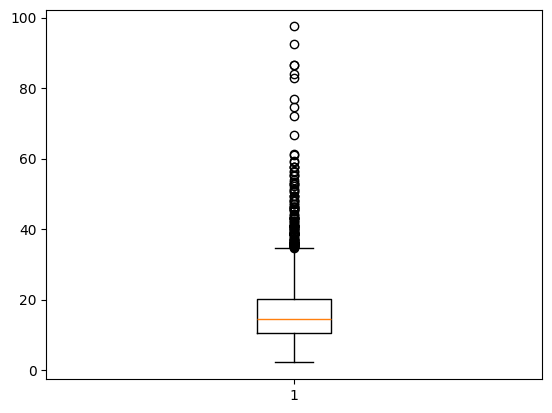

In [30]:
def z3():
    year = data['age']
    plt.boxplot(year)
    print(year)
    plt.show()
    finance = data['earnings']
    plt.boxplot(finance)
    plt.show()

z3()

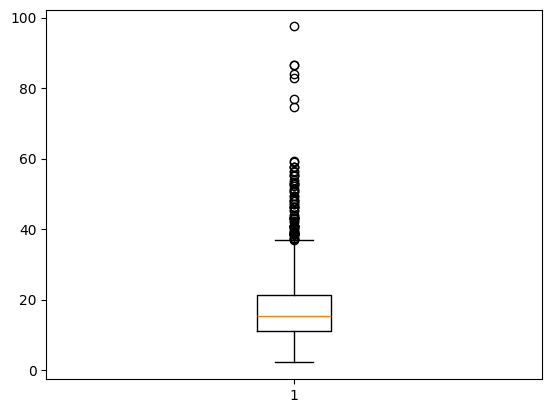

In [31]:
male_data = data.loc[data['gender'] == 'male', 'earnings']
plt.boxplot(male_data)
plt.show()

Średnia: 9.92819483148823
Mediana: 9.903257863323315
IQR: 6.590039887848251
Variance: 24.42420993476097
Sigma: 4.942085585535824
Kurtoza: 2.8940680314572775
Kurtoza: 0.05086490540164201


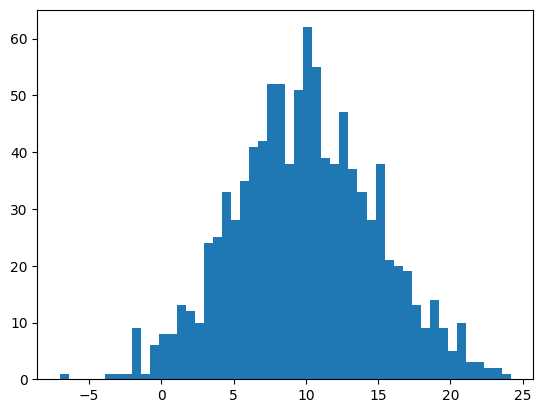

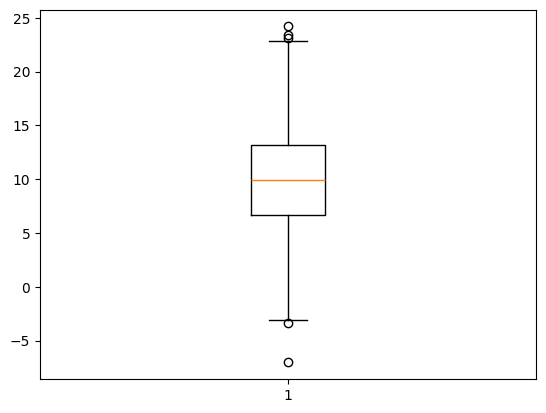

AttributeError: 'numpy.ndarray' object has no attribute 'append'

In [ ]:
def show_statistics(X):
    print(f'Średnia: {np.mean(X)}')
    print(f'Mediana: {np.median(X)}')
    print(f'IQR: {IQR(X)}')
    print(f'Variance: {Var(X)}')
    print(f'Sigma: {np.sqrt(Var(X))}')
    print(f'Kurtoza: {sc.kurtosis(X, bias=False, fisher=False)}')
    print(f'Kurtoza: {sc.skew(X, bias=False)}')
    x = np.linspace(5, 100, num=len(X))
    plt.hist(X, bins=50)
    plt.show()
    plt.boxplot(X)
    plt.show()

X = np.random.normal(10, 5, size=1000)
U = np.random.uniform(low=50, high=100, size=10)

show_statistics(X)
X2 = []
for x in X:
    X2.append(x)
for u in U:
    X2.append(u)
show_statistics(X2)
